In [1]:
import requests
import pandas as pd

#Call the FHIR server
url = "https://hapi.fhir.org/baseR4/Patient"
params = {"_count": 20}

response = requests.get(url, params=params)
data = response.json()

# Parse into a list
rows =[]
for entry in data.get("entry", []):
    p = entry["resource"]
    name = p.get("name", [{}])[0]
    rows.append({
        "id": p.get("id"),
        "family": name.get("family"),
        "given": str(name.get("given", [])),
        "gender": p.get("gender"),
        "birthDate": p.get("birthDate")
    })

# Turn into DataFrame
df = pd.DataFrame(rows)
print(df.shape)
df.head(10)


(20, 5)


,id,family,given,gender,birthDate
0,131896579,Ramirez,['Carlos'],male,1974-05-12
1,131707439,Williams,['Maria'],female,1972-06-15
2,132080085,RATA,['JOHN'],male,1971
3,132080089,Cientanni,['Mariagiusy'],female,None
4,132080095,Sharma,['Rahul'],male,1995-01-01
5,132080098,Sharma,['Rahul'],male,1995-01-01
6,132080102,TestFamily,['TestGiven'],male,None
7,132080103,Sharma,['Rahul'],male,1995-01-01
8,132080109,Sharma,['Rahul'],male,1995-01-01
9,132080123,Hilll,['Ashleigh'],female,2000-11-13


In [2]:
# Check for missing values and data types
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nGender distribution:")
print(df['gender'].value_counts())

id           object
family       object
given        object
gender       object
birthDate    object
dtype: object

Missing values:
id           0
family       0
given        0
gender       0
birthDate    6
dtype: int64

Gender distribution:
gender
male       14
female      4
other       1
unknown     1
Name: count, dtype: int64


In [3]:
# Pull observations (vitals + labs)
obs_rows = []

for patient_id in df['id'].dropna():
    obs_url = "https://hapi.fhir.org/baseR4/Observation"
    obs_params = {"patient": patient_id, "_count": 5}
    obs_response = requests.get(obs_url, params=obs_params)
    obs_data = obs_response.json()
    
    for entry in obs_data.get("entry", []):
        o = entry["resource"]
        code = o.get("code", {})
        coding = code.get("coding", [{}])[0]
        value = o.get("valueQuantity", {})
        
        obs_rows.append({
            "patient_id": patient_id,
            "loinc_code": coding.get("code"),
            "display": coding.get("display") or code.get("text"),
            "value": value.get("value"),
            "unit": value.get("unit")
        })

obs_df = pd.DataFrame(obs_rows)
print(obs_df.shape)
obs_df.head(10)

(9, 5)


,patient_id,loinc_code,display,value,unit
0,131896579,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,9.4,%
1,131896579,2345-7,Glucose [Mass/volume] in Serum or Plasma,268.0,mg
2,131896579,2823-3,Potassium [Moles/volume] in Serum or Plasma,6.2,mmol/L
3,131896579,2093-3,Cholesterol [Mass/volume] in Serum or Plasma,242.0,mg/dL
4,131707439,4548-4,Hemoglobin A1c,NaN,None
5,131707439,2345-7,Glucose,287.0,mg
6,131707439,2093-3,Total Cholesterol,238.0,mg/dL
7,131707439,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,8.2,%
8,131707439,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,9.1,%


In [4]:
# What LOINC codes appear most frequently?
print(obs_df['display'].value_counts().head(10))

display
Hemoglobin A1c/Hemoglobin.total in Blood        3
Glucose [Mass/volume] in Serum or Plasma        1
Potassium [Moles/volume] in Serum or Plasma     1
Cholesterol [Mass/volume] in Serum or Plasma    1
Hemoglobin A1c                                  1
Glucose                                         1
Total Cholesterol                               1
Name: count, dtype: int64


In [5]:
# Pull observations directly from the server
obs_url = "https://hapi.fhir.org/baseR4/Observation"
obs_params = {"_count": 50, "status": "final"}

obs_response = requests.get(obs_url, params=obs_params)
obs_data = obs_response.json()

obs_rows = []
for entry in obs_data.get("entry", []):
    o = entry["resource"]
    code = o.get("code", {})
    coding = code.get("coding", [{}])[0]
    value = o.get("valueQuantity", {})
    category = o.get("category", [{}])[0].get("coding", [{}])[0]
    
    obs_rows.append({
        "patient_id": o.get("subject", {}).get("reference"),
        "category": category.get("code"),
        "loinc_code": coding.get("code"),
        "display": coding.get("display") or code.get("text"),
        "value": value.get("value"),
        "unit": value.get("unit")
    })

obs_df = pd.DataFrame(obs_rows)
print(obs_df.shape)
obs_df.head(10)

(50, 6)


,patient_id,category,loinc_code,display,value,unit
0,None,vital-signs,8867-4,Heart rate,102.0,/min
1,None,vital-signs,2708-6,saturation in Arterial blood,98.0,%
2,Patient/89980748,None,8867-4,Heart rate,102.0,beats/min
3,Patient/89181703,None,8462-4,Diastolic blood pressure,79.0,mmHg
4,Patient/89980748,None,8310-5,Fever,100.4,degF
5,Patient/89980748,None,8480-6,Diastolic blood pressure,80.0,mmHg
6,Patient/cfsb1761834255983,None,8302-2,Body height,165.0,cm
7,Patient/testmartin,laboratory,718-7,Hemoglobin [Mass/volume] in Blood,14.5,g/dL
8,Patient/testmartin,laboratory,2345-7,Glucose [Mass/volume] in Blood,95.0,mg/dL
9,Patient/testmartin,laboratory,2093-3,Cholesterol [Mass/volume] in Serum or Plasma,182.0,mg/dL


In [6]:
print(obs_df['display'].value_counts().head(10))
print("\nCategories found:")
print(obs_df['category'].value_counts())


display
Heart rate                                      4
Environmental Air Pollution Exposure            4
Platelets [#/volume] in Blood                   3
Microalbuminuria (orina)                        3
Triglicéridos                                   3
Colesterol LDL                                  3
Hemoglobina glicosilada (HbA1c)                 3
Glucosa en plasma                               3
Creatinina sérica                               3
Cholesterol [Mass/volume] in Serum or Plasma    3
Name: count, dtype: int64

Categories found:
category
laboratory     30
vital-signs     6
Name: count, dtype: int64


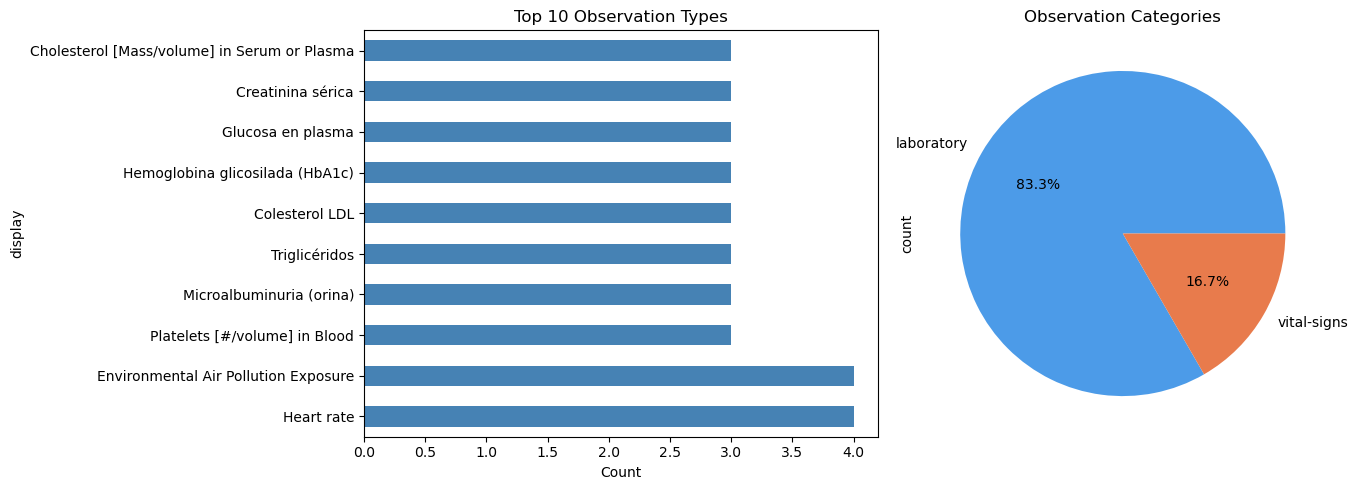

Chart saved!


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Top observations by frequency
obs_df['display'].value_counts().head(10).plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Top 10 Observation Types')
axes[0].set_xlabel('Count')

# Chart 2 — Category breakdown
obs_df['category'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#4C9BE8', '#E87B4C']
)
axes[1].set_title('Observation Categories')

plt.tight_layout()
plt.savefig('fhir_observations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [8]:
# Pull Condition resources
cond_url = "https://hapi.fhir.org/baseR4/Condition"
cond_params = {"_count": 50, "clinical-status": "active"}

cond_response = requests.get(cond_url, params=cond_params)
cond_data = cond_response.json()

cond_rows = []
for entry in cond_data.get("entry", []):
    c = entry["resource"]
    code = c.get("code", {})
    coding = code.get("coding", [{}])[0]
    
    cond_rows.append({
        "patient_id": c.get("subject", {}).get("reference"),
        "condition_code": coding.get("code"),
        "condition_system": coding.get("system"),
        "condition_text": code.get("text") or coding.get("display"),
        "status": c.get("clinicalStatus", {}).get("coding", [{}])[0].get("code"),
        "recorded_date": c.get("recordedDate")
    })

cond_df = pd.DataFrame(cond_rows)
print(cond_df.shape)
cond_df.head(10)

(50, 6)


,patient_id,condition_code,condition_system,condition_text,status,recorded_date
0,Patient/98067569,None,None,"Unilateral primary osteoarthritis, right knee",active,2022-05-15
1,Patient/ailovdisyb2,None,None,Asthma,active,None
2,Patient/CC-12345678,None,None,Hipertensión esencial,active,None
3,Patient/lalo2,None,None,Asthma,active,None
4,Patient/frt2,386661006,http://snomed.info/sct,Cashew nuts,active,None
5,Patient/123836453,195917001,http://snomed.info/sct,asthma,active,None
6,Patient/123836453,73211009,http://snomed.info/sct,diabetes,active,None
7,Patient/123836453,38341003,http://snomed.info/sct,hypertension,active,None
8,Patient/123836453,35489007,http://snomed.info/sct,depression,active,None
9,Patient/123836453,247389009,http://snomed.info/sct,neuropathic pain,active,None


In [9]:
# Pull MedicationRequest resources
med_url = "https://hapi.fhir.org/baseR4/MedicationRequest"
med_params = {"_count": 50, "status": "active"}

med_response = requests.get(med_url, params=med_params)
med_data = med_response.json()

med_rows = []
for entry in med_data.get("entry", []):
    m = entry["resource"]
    med = m.get("medicationCodeableConcept", {})
    coding = med.get("coding", [{}])[0]
    
    med_rows.append({
        "patient_id": m.get("subject", {}).get("reference"),
        "rxnorm_code": coding.get("code"),
        "medication": coding.get("display") or med.get("text"),
        "status": m.get("status"),
        "authored_date": m.get("authoredOn"),
        "intent": m.get("intent")
    })

med_df = pd.DataFrame(med_rows)
print(med_df.shape)
med_df.head(10)

(50, 6)


,patient_id,rxnorm_code,medication,status,authored_date,intent
0,Patient/90117077,387517004,Insulin glargine,active,2026-02-18T17:34:51+05:30,order
1,Patient/AtEmedExamplePatient01,None,None,active,2026-01-28T08:00:00+00:00,order
2,Patient/AtEmedExamplePatient01,None,None,active,2026-01-28T08:00:00+00:00,order
3,Patient/131268946,None,None,active,2026-02-25,plan
4,Patient/131286974,None,None,active,2026-02-25,plan
5,Patient/131287660,105376,Metformin hydrochloride 500 MG Oral Tablet,active,None,order
6,Patient/131288052,135451,Memantine 10mg,active,2024-09-01,order
7,Patient/131288089,191831,Infliximab 400mg IV,active,2023-01-10,order
8,Patient/131288089,1256,Azathioprine 150mg,active,2023-01-10,order
9,Patient/131288089,4316,Ferrous Sulfate 325mg,active,2025-01-15,order


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/figures/fhir_dashboard.png'

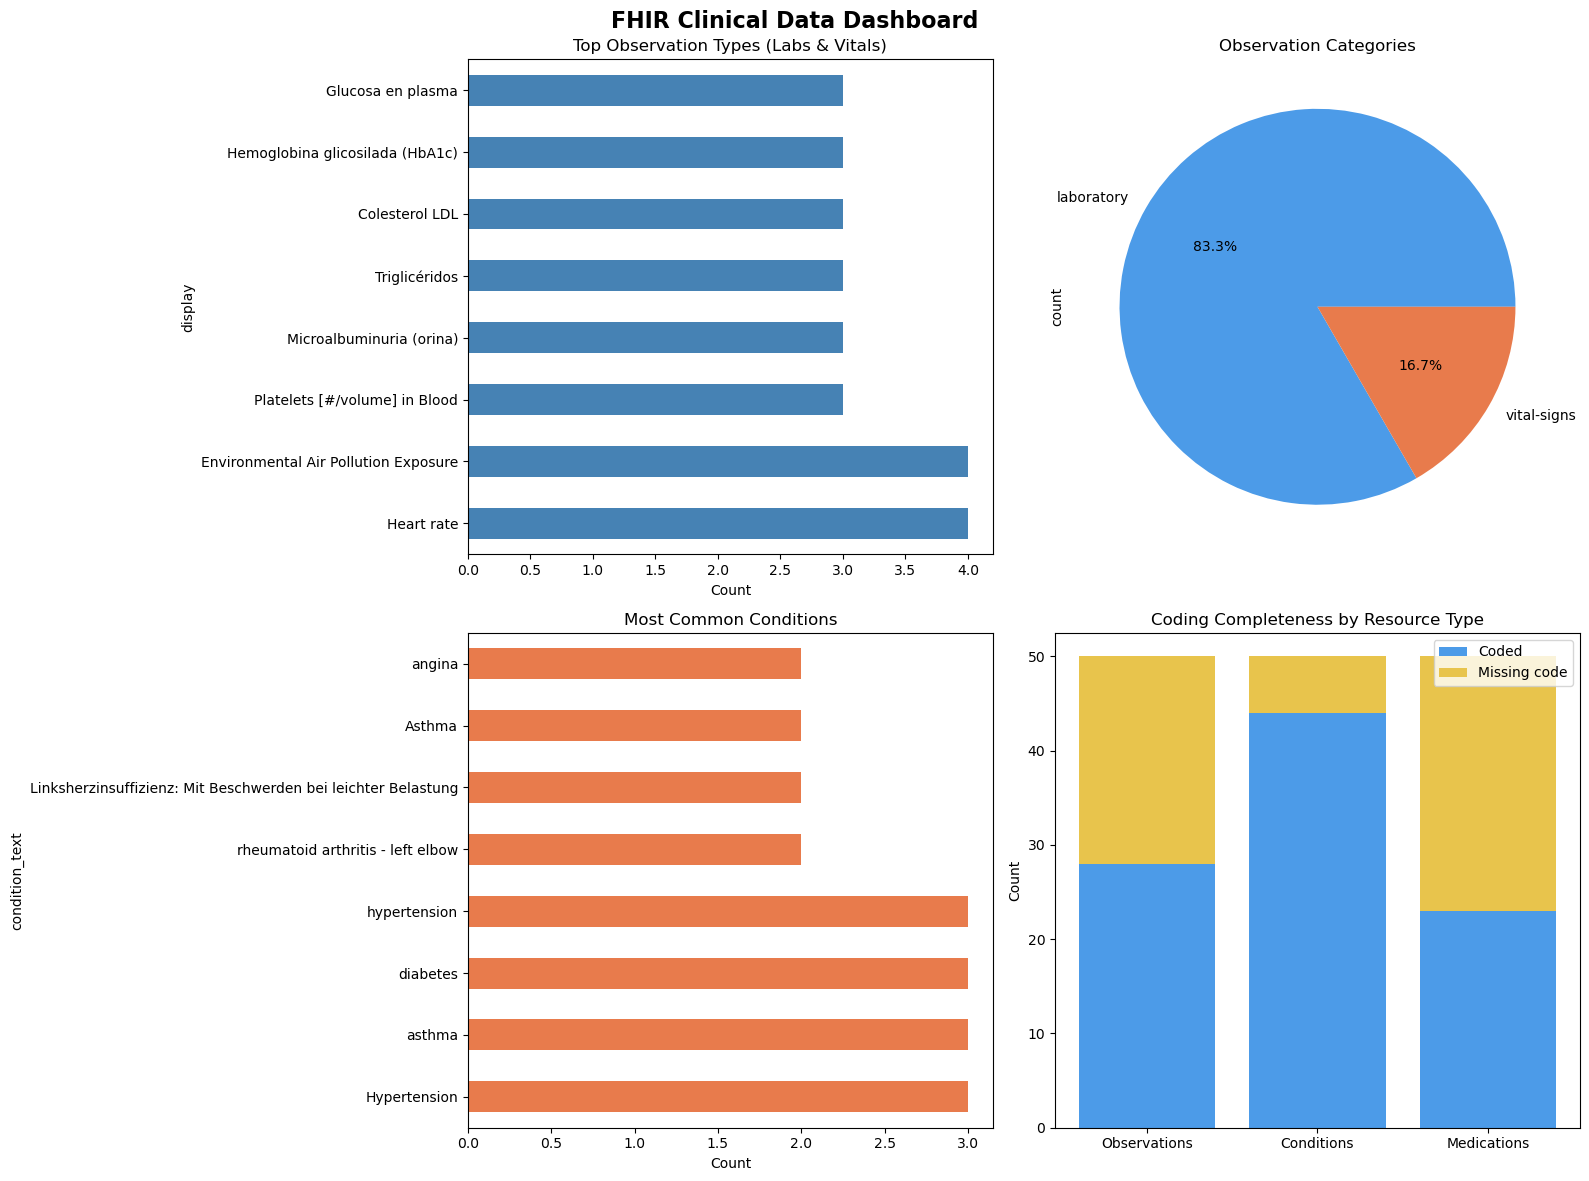

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('FHIR Clinical Data Dashboard', fontsize=16, fontweight='bold')

# Chart 1 — Top observation types
obs_df['display'].value_counts().head(8).plot(
    kind='barh', ax=axes[0,0], color='steelblue'
)
axes[0,0].set_title('Top Observation Types (Labs & Vitals)')
axes[0,0].set_xlabel('Count')

# Chart 2 — Observation categories
obs_df['category'].value_counts().plot(
    kind='pie', ax=axes[0,1], autopct='%1.1f%%',
    colors=['#4C9BE8', '#E87B4C']
)
axes[0,1].set_title('Observation Categories')

# Chart 3 — Top conditions
cond_df['condition_text'].value_counts().head(8).plot(
    kind='barh', ax=axes[1,0], color='#E87B4C'
)
axes[1,0].set_title('Most Common Conditions')
axes[1,0].set_xlabel('Count')

# Chart 4 — Coding completeness across all resources
labels = ['Observations', 'Conditions', 'Medications']
coded = [
    obs_df['loinc_code'].notna().sum(),
    cond_df['condition_code'].notna().sum(),
    med_df['rxnorm_code'].notna().sum()
]
uncoded = [
    obs_df['loinc_code'].isna().sum(),
    cond_df['condition_code'].isna().sum(),
    med_df['rxnorm_code'].isna().sum()
]

x = range(len(labels))
axes[1,1].bar(x, coded, label='Coded', color='#4C9BE8')
axes[1,1].bar(x, uncoded, bottom=coded, label='Missing code', color='#E8C44C')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(labels)
axes[1,1].set_title('Coding Completeness by Resource Type')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('outputs/figures/fhir_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

In [11]:
import os
os.makedirs(os.path.expanduser('~/Documents/fhir-patient-explorer/outputs/figures'), exist_ok=True)
plt.savefig(os.path.expanduser('~/Documents/fhir-patient-explorer/outputs/figures/fhir_dashboard.png'), 
            dpi=150, bbox_inches='tight')
print("Saved!")

Saved!


<Figure size 640x480 with 0 Axes>